<a href="https://colab.research.google.com/github/vicavica/Basics-of-Python-Programming---OpenSource-based-data-analysis_Incomplete/blob/main/%EC%98%A4%EB%8D%B0_%EC%A4%91%EA%B0%84%EA%B3%BC%EC%A0%9C%EB%AC%BC3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

## 모든 월 데이터를 저장할 리스트
all_data = []

##2015년 1월부터 2024년 12월까지 url 호출
years = range(2015, 2025)
months = range(1, 13)
for year in years:
    for month in months:
        month_str = str(month).zfill(2) #월 두자리로 출력
        url = f"http://openapi.seoul.go.kr:8088/66447a6465746864373453456b464b/json/energyUseDataSummaryInfo/1/5/{year}/{month_str}"

        ## 월 데이터 수집
        response = requests.get(url)

        ## 호출 성공/실패 출력
        if response.status_code == 200:
            print(f"{year}년 {month}월 API 호출 성공")  #____년 __월 API 호출 성공 출력
            #print(response.json())
            ## 수집된 월 데이터 저장(requests로부터 energyUseDataSummaryInfo, row 항목)
            data = response.json()['energyUseDataSummaryInfo']['row']
            ## 저장된 월 데이터 리스트에 누적
            all_data.extend(data)
        else:
            print(f"{year}년 {month}월 API 호출 실패: {response.status_code}")

print(type(all_data))
print(len(all_data))
print(all_data[0])

2015년 1월 API 호출 성공
2015년 2월 API 호출 성공
2015년 3월 API 호출 성공
2015년 4월 API 호출 성공
2015년 5월 API 호출 성공
2015년 6월 API 호출 성공
2015년 7월 API 호출 성공
2015년 8월 API 호출 성공
2015년 9월 API 호출 성공
2015년 10월 API 호출 성공
2015년 11월 API 호출 성공
2015년 12월 API 호출 성공
2016년 1월 API 호출 성공
2016년 2월 API 호출 성공
2016년 3월 API 호출 성공
2016년 4월 API 호출 성공
2016년 5월 API 호출 성공
2016년 6월 API 호출 성공
2016년 7월 API 호출 성공
2016년 8월 API 호출 성공
2016년 9월 API 호출 성공
2016년 10월 API 호출 성공
2016년 11월 API 호출 성공
2016년 12월 API 호출 성공
2017년 1월 API 호출 성공
2017년 2월 API 호출 성공
2017년 3월 API 호출 성공
2017년 4월 API 호출 성공
2017년 5월 API 호출 성공
2017년 6월 API 호출 성공
2017년 7월 API 호출 성공
2017년 8월 API 호출 성공
2017년 9월 API 호출 성공
2017년 10월 API 호출 성공
2017년 11월 API 호출 성공
2017년 12월 API 호출 성공
2018년 1월 API 호출 성공
2018년 2월 API 호출 성공
2018년 3월 API 호출 성공
2018년 4월 API 호출 성공
2018년 5월 API 호출 성공
2018년 6월 API 호출 성공
2018년 7월 API 호출 성공
2018년 8월 API 호출 성공
2018년 9월 API 호출 성공
2018년 10월 API 호출 성공
2018년 11월 API 호출 성공
2018년 12월 API 호출 성공
2019년 1월 API 호출 성공
2019년 2월 API 호출 성공
2019년 3월 API 호출 성공
2019년 4월 API 호출 성공


In [ ]:
import pandas as pd
#df 변환
df = pd.DataFrame(all_data)

#DataFrame 인덱스로 지정
df = df.set_index('MM_TYPE')

#DataFrame 개인 행 선택
df= df.loc['개인']

#개인 인덱스 삭제
df = df.reset_index(drop=True)

#YEAR, MON, EUS, GUS, WUS, HUS 열 선택
df = df[['YEAR', 'MON', 'EUS', 'GUS', 'WUS', 'HUS']]
df

#열이름 변경(연도 월, 전기, 가스, 수도, 지역난방 에너지 사용량)
df = df.rename(columns={'YEAR': '연도', 'MON': '월', 'EUS':'전기', 'GUS':'가스', 'WUS':'수도', 'HUS':'지역난방'})

#df 복수 열 오름차순, 오름차순 정렬
df.sort_values(by=['연도','월'], ascending=[True, True])

## 데이터의 기본 정보 출력
#스키마
print("[스키마]")
print(df.dtypes)
print("\n")
#info
print("[info]")
print(df.info())
print("\n")
#describe
print("[describe]")
print(df.describe())
#df
df

[스키마]
연도      object
월       object
전기      object
가스      object
수도      object
지역난방    object
dtype: object


[info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연도      83 non-null     object
 1   월       83 non-null     object
 2   전기      83 non-null     object
 3   가스      83 non-null     object
 4   수도      83 non-null     object
 5   지역난방    83 non-null     object
dtypes: object(6)
memory usage: 4.0+ KB
None


[describe]
          연도   월         전기        가스            수도          지역난방
count     83  83         83        83            83            83
unique    10  12         83        83            83            83
top     2024  11  193784708  59133720  12819757.886  22740838.937
freq      12   9          1         1             1             1


,연도,월,전기,가스,수도,지역난방
0,2015,01,193784708,59133720,12819757.886,22740838.937
1,2015,02,189974230,56487358,12656888.218,18793320.213
2,2015,05,177289769,22060892,13086734.214,1320895.801
3,2015,06,186073153,12677645,14241651.402,294312.634
4,2015,07,165114568,8893640,12083879.038,702863.645
...,...,...,...,...,...,...
78,2024,08,463971328,7072251,15873544.6,130082.263
79,2024,09,409872908,5729131,15143321.6,3420507.136
80,2024,10,282268119,8233421,15297669.9,2695491.396
81,2024,11,257927956,17418221,14678672.5,8836296.454


In [ ]:
## csv 형식 데이터 저장
df.to_csv('energy.csv', index=False, encoding='utf-8')

In [ ]:
en = pd.read_csv('energy.csv')

#연도(year)로 연도 이름 변경
df = df.rename(columns={'연도':'연도(year)'})

# 정수 혹은 실수로 변환
df['연도(year)'] = df['연도(year)'].astype(int)
df['월'] = df['월'].astype(int)
df['전기'] = df['전기'].astype(float)
df['가스'] = df['가스'].astype(float)
df['수도'] = df['수도'].astype(float)
df['지역난방'] = df['지역난방'].astype(float)

# 날짜 열 추가(날짜는 편의상 1일로 지정)
df['날짜'] = pd.to_datetime(df['연도(year)'].astype(str) + '-' + df['월'].astype(str) + '-01')
print(df[['연도(year)', '월', '날짜']].head())

#계절(season) 열 추가
def season(month):
    if 3 <= month <= 5:
        return '봄'
    elif 6 <= month <= 8:
        return '여름'
    elif 9 <= month <= 11:
        return '가을'
    else:
        return '겨울'
df['계절(season)'] = df['월'].apply(season)

# DataFrame 열순서 변경
df = df[['날짜', '계절(season)', '연도(year)', '월', '전기', '가스', '수도', '지역난방']]
df

   연도(year)  월         날짜
0      2015  1 2015-01-01
1      2015  2 2015-02-01
2      2015  5 2015-05-01
3      2015  6 2015-06-01
4      2015  7 2015-07-01


,날짜,계절(season),연도(year),월,전기,가스,수도,지역난방
0,2015-01-01,겨울,2015,1,193784708.0,59133720.0,1.281976e+07,2.274084e+07
1,2015-02-01,겨울,2015,2,189974230.0,56487358.0,1.265689e+07,1.879332e+07
2,2015-05-01,봄,2015,5,177289769.0,22060892.0,1.308673e+07,1.320896e+06
3,2015-06-01,여름,2015,6,186073153.0,12677645.0,1.424165e+07,2.943126e+05
4,2015-07-01,여름,2015,7,165114568.0,8893640.0,1.208388e+07,7.028636e+05
...,...,...,...,...,...,...,...,...
78,2024-08-01,여름,2024,8,463971328.0,7072251.0,1.587354e+07,1.300823e+05
79,2024-09-01,가을,2024,9,409872908.0,5729131.0,1.514332e+07,3.420507e+06
80,2024-10-01,가을,2024,10,282268119.0,8233421.0,1.529767e+07,2.695491e+06
81,2024-11-01,가을,2024,11,257927956.0,17418221.0,1.467867e+07,8.836296e+06


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache –fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


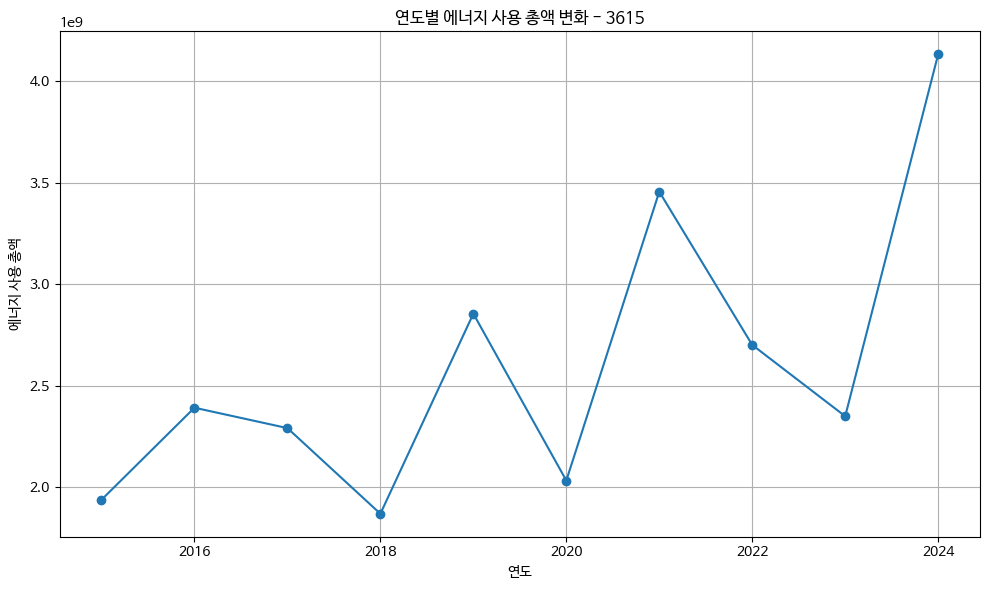

In [ ]:
### 시각화 라이브러리 임포트
import matplotlib.pyplot as plt
### 나눔바른고딕 글꼴 설정
plt.rc('font', family='NanumBarunGothic')

# 연도별 에너지 사용 총 사용량(전기+가스+수도+지역난방) 계산
df['총에너지'] = df['전기'] + df['가스'] + df['수도'] + df['지역난방']
yearly_total = df.groupby('연도(year)')['총에너지'].sum().reset_index()

## 선 그래프 시각화
#그래프 크기 지정
plt.figure(figsize=(10,6))
#선 그래프 생성
plt.plot(yearly_total['연도(year)'], yearly_total['총에너지'], marker='o', linestyle='-')
plt.title("연도별 에너지 사용 총액 변화 - 3615")
plt.xlabel("연도")
plt.ylabel("에너지 사용 총액")
plt.grid(True)
plt.tight_layout()

# 그래프 저장
plt.savefig("연도별 에너지 사용 총액 변화 - 3615.png")
plt.show()

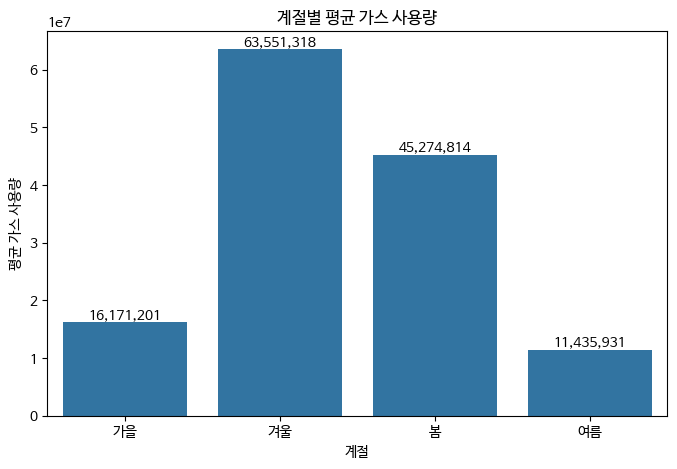

In [ ]:
### 시각화 라이브러리 추가
import matplotlib.pyplot as plt
import seaborn as sns

## 계절별 가스 사용량 평균을 계산
season_gas_avg = df.groupby('계절(season)')['가스'].mean().reset_index()

## 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x='계절(season)', y='가스', data=season_gas_avg)
plt.title("계절별 평균 가스 사용량")
plt.xlabel("계절")
plt.ylabel("평균 가스 사용량")

## 각 막대에 수치 표시
for i, val in enumerate(season_gas_avg['가스']):
    plt.text(x=i,                # x좌표: 막대 인덱스
             y=val,              # y좌표: 막대 높이
             s=f'{val:,.0f}',    # 표시할 값, 쉼표 추가
             ha='center',        # 가로 중앙 정렬
             va='bottom')        # 막대 바로 위에 표시
plt.show()